## Imports das Bibliotecas

In [3]:
## Imports Geral
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import nltk
import numpy as np 

# Import para Visualização de Dados
from wordcloud import WordCloud

# Extração de Texto
from nltk.corpus import stopwords

# Importações de Metrica
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Preprocessamento
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

# Modelos
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

import warnings

# Suprimir todos os warnings
warnings.filterwarnings("ignore")

# DESENVOLVER O MODELO SEM VIES 

# Analise dos dados

In [4]:
df = pd.read_csv("./cor_da_justica.csv")
remover_colunas = ["Unnamed: 0", "uris.uriAutores", "uris.uriPropPrincipal",
                   "uris.uriUltimoRelator", "foto", "cpf", ]
df = df.drop(columns=remover_colunas)
df = df.dropna(subset=["ementa"])
df = df.drop_duplicates()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10790 entries, 0 to 11736
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   ementa                 10790 non-null  object
 1   ementaDetalhada        491 non-null    object
 2   ano                    10790 non-null  int64 
 3   keywords               5071 non-null   object
 4   nome                   10790 non-null  object
 5   sexo                   10790 non-null  object
 6   nascimento             10790 non-null  object
 7   local_nascimento       10790 non-null  object
 8   escolaridade           10531 non-null  object
 9   uris.uriPartido        10790 non-null  object
 10  ementa_principal       10790 non-null  object
 11  situacao               2068 non-null   object
 12  tipo                   2242 non-null   object
 13  keywords_principal     2219 non-null   object
 14  nome_partido           10790 non-null  object
 15  sigla_partido          1

In [5]:
df["ementa"] = df.apply(lambda x: x["ementa"] + ' ' +  x["ementaDetalhada"] if x["ementaDetalhada"] == str(x["ementaDetalhada"]) else x["ementa"] , axis=1)
df["ementa"] = df.apply(lambda x: x["ementa"] + ' ' +  x["ementa_principal"] if x["ementa_principal"] != str("vazio") else x["ementa"] , axis=1)
df["ementa"] = df.apply(lambda x: x["ementa"] + ' ' +  x["keywords"] if x["keywords"] == str(x["keywords"]) else x["ementa"] , axis=1)
df["ementa"] = df.apply(lambda x: x["ementa"] + ' ' +  x["keywords_principal"] if x["keywords_principal"] == str(x["keywords_principal"]) else x["ementa"] , axis=1)

In [6]:
df = df.drop(columns=["ementaDetalhada", "ementa_principal", 'keywords', 'keywords_principal'])

In [7]:
df["situacao"].loc[(df["situacao"] == "Aguardando Designação de Relator(a)" ) | (df["situacao"] == "Aguardando Parecer") | (df["situacao"] == "Aguardando Encaminhamento") | (df["situacao"] == "Aguardando Definição Encaminhamento") | (df["situacao"] == "Aguardando Recurso") | (df["situacao"] == "Aguardando Despacho de Arquivamento ") | (df["situacao"] == "Aguardando Deliberação")  | (df["situacao"] == "Aguardando Designação - Aguardando Devolução de Relator(a) que deixou de ser Membro") | (df["situacao"] == "Aguardando Análise de Parecer") | (df["situacao"] == "Arquivada") ] = "AGUARDANDO"
df["situacao"].loc[(df["situacao"] == "Tramitando em Conjunto" ) | (df["situacao"] == "Pronta para Pauta")] = "TRAMITANDO"
df["situacao"] = df["situacao"].fillna("RECUSADO")

In [8]:
df = df.drop(df[(df['cor'] == "#NE") | (
    df["cor"] == "#NE#") | (df["cor"] == "NÃO DIVULGÁVEL")].index).reset_index(drop=True)

df["cor"].loc[(df["cor"] == "AMARELA") | (df["cor"] == "INDÍGENA") | (df["cor"] == "PARDA") | (df["cor"] == "PRETA")] = "OUTROS"

In [9]:
df['cor'].value_counts()

cor
BRANCA    3421
OUTROS    1397
Name: count, dtype: int64

In [10]:
# # y_pred = model_LR.predict(X)
# # rng = np.random.default_rng(42)
# rng = np.random.default_rng(62)
# numbers = rng.random(len(df))
# balanceamento = [df.loc[df["cor"] == "BRANCA"].sample(1)  if i < prob_brancos else df.loc[df['cor'] == 'OUTROS'].sample(1) for i in numbers]
# df = pd.concat(balanceamento)


In [11]:
# df["nome"].value_counts().unique()
df["ementa"].count()

4818

In [12]:
cor = df["cor"].value_counts().reset_index()
cor["cor"].unique()
cor

,cor,count
0,BRANCA,3421
1,OUTROS,1397


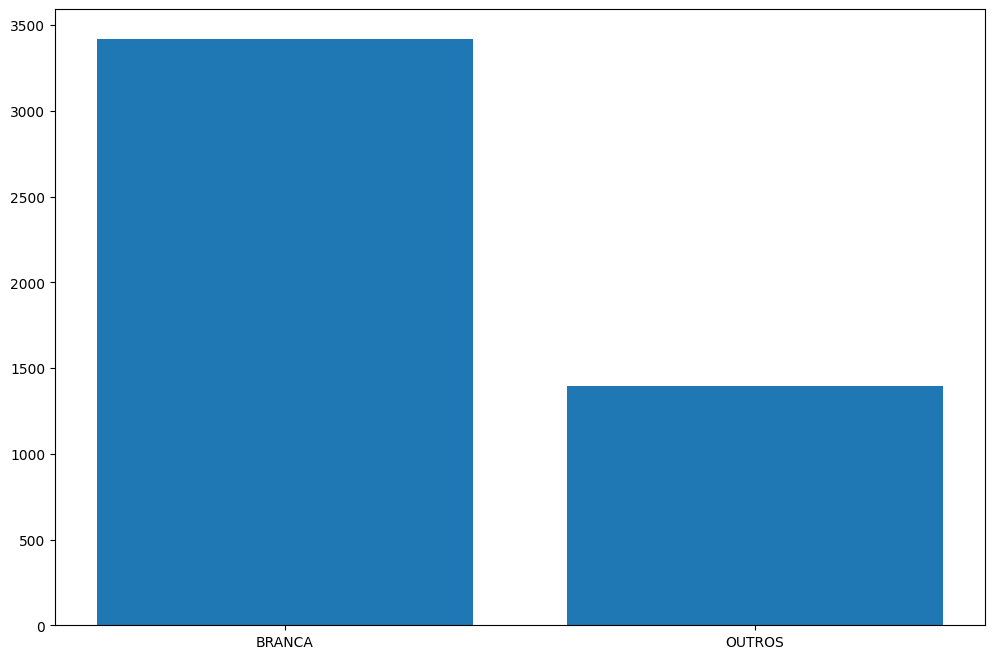

In [13]:
fx, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.bar(cor["cor"], height=cor["count"])
plt.show()

In [14]:
df["ementa"].dropna().count()

4818

## Bag Of Words

In [15]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /home/xandy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [16]:
df = df.dropna(subset=["ementa"]).reset_index(drop=True)

In [17]:
tf_idf = TfidfVectorizer(stop_words=(stopwords.words('portuguese')), ngram_range=(1,1) )
X = tf_idf.fit_transform(df["ementa"])
vocab = tf_idf.get_feature_names_out()
vocab = ' '.join(vocab)


## WORD CLOUD

In [18]:
le = LabelEncoder()

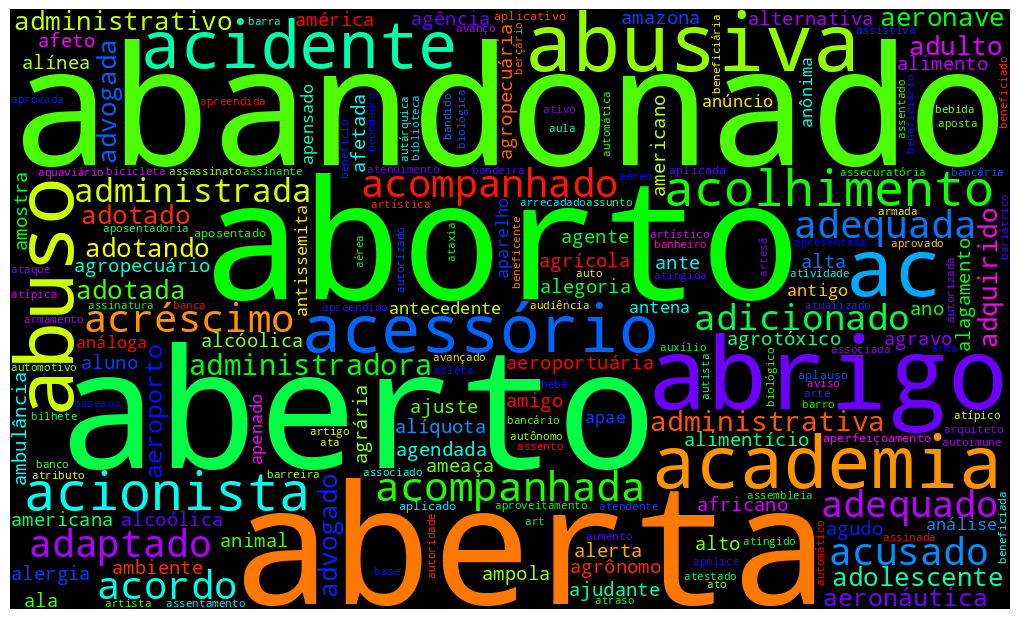

In [19]:
# Juntar as strings em uma única string separada por espaços
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color='black',
    colormap='gist_rainbow',
    min_font_size=10).generate(vocab)

plt.figure(figsize=(10, 6), facecolor=None)
plt.imshow(wordcloud)
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()

In [20]:
df_brancos = df[df["cor"] == "BRANCA"]
df_outros  = df[df["cor"] == "OUTROS"]




tf_idf_brancos = TfidfVectorizer(stop_words=(stopwords.words('portuguese')), ngram_range=(1,1) )
tf_idf_outros = TfidfVectorizer(stop_words=(stopwords.words('portuguese')), ngram_range=(1,1) )


y_brancos = le.fit_transform(df_brancos["situacao"])
y_outros = le.fit_transform(df_outros["situacao"])


In [21]:
X_brancos = tf_idf_brancos.fit_transform(df_brancos["ementa"])
vocab_brancos = tf_idf_brancos.get_feature_names_out()
vocab_brancos = ' '.join(vocab_brancos)


In [22]:
tf_idf_brancos.get_feature_names_out()
palavras = tf_idf_brancos.vocabulary_
palavras

# palavras.keys()
# palavras.values()


# palavras = pd.DataFrame(data=palavras)

for item in sorted(palavras, key = palavras.get, reverse=True):
    print(f'{item}  {palavras[item]}')

útero  10451
único  10450
últimos  10449
último  10448
ônus  10447
ônibus  10446
ótico  10445
ótica  10444
óssea  10443
órteses  10442
órtese  10441
órgãos  10440
órgão  10439
órfãos_  10438
órfãos  10437
órfão  10436
óptica  10435
óleo  10434
ódio  10433
óbito  10432
íntimo  10431
índice  10430
ênfase  10429
étnico  10428
éticos  10427
ético  10426
ética  10425
éden  10424
çairé  10423
ão  10422
âmbitos  10421
âmbito  10420
áustria  10419
áudio  10418
árvore  10417
áreas  10416
área  10415
árbitro  10414
álcool  10413
águas  10412
água  10411
ágape  10410
ácido  10409
àquele  10408
àquela  10407
zóster  10406
zé  10405
zoster  10404
zoonoses  10403
zoonose  10402
zoneamento  10401
zona  10400
zika  10399
zfm  10398
zero  10397
zeno  10396
zeni  10395
zenaide  10394
zee  10393
zanatta  10392
zacharias  10391
youtube  10390
xxxiii  10389
xxiv  10388
xxi  10387
xvii  10386
xliii  10385
xiv  10384
xisto  10383
xingu  10382
xiii  10381
xi  10380
xenofobia  10379
xambioá  10378
woman  10377

In [23]:
palavras['abandono']

1177

In [24]:
X_outros = tf_idf.fit_transform(df_outros["ementa"])
vocab_outros = tf_idf.get_feature_names_out()
vocab_outros = ' '.join(vocab_outros)


In [25]:
X_brancos

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 90369 stored elements and shape (3421, 10452)>

## GRUPO 1: PESSOA DE COR DE PELE BRANCA

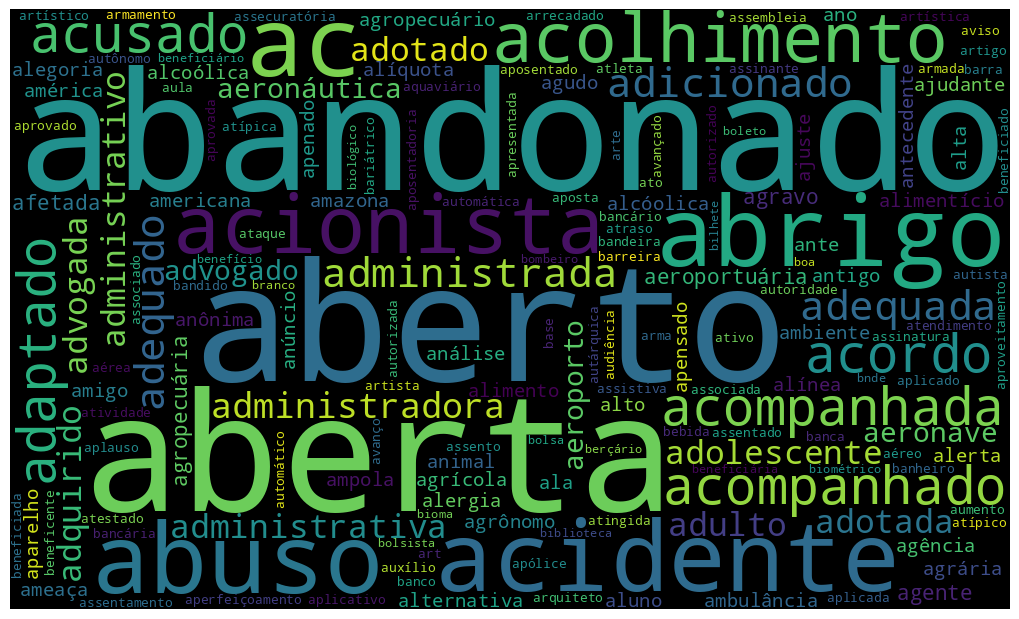

In [26]:

# Juntar as strings em uma única string separada por espaços
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color='black',
    min_font_size=10).generate(vocab_brancos)
plt.figure(figsize=(10, 6), facecolor=None)
plt.imshow(wordcloud)
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()

## GRUPO 2: PESSOA DE COR DE PELE DIFERENTES 

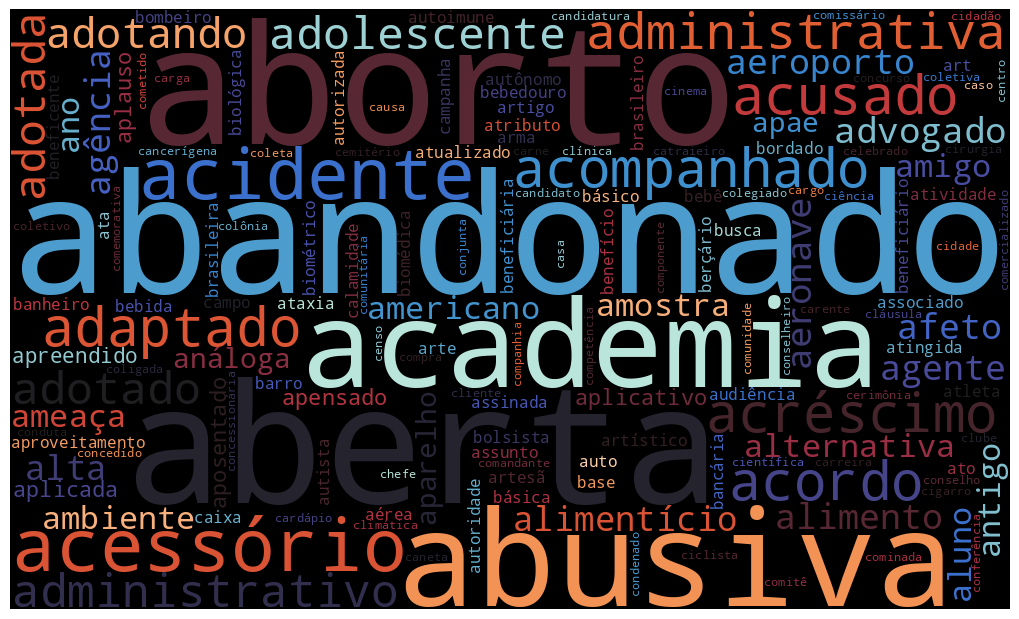

In [27]:

# Juntar as strings em uma única string separada por espaços
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color='black',
    colormap='icefire',
    min_font_size=10).generate(vocab_outros)
plt.figure(figsize=(10, 6), facecolor=None)
plt.imshow(wordcloud)
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()

# PCA

In [28]:
df['cor']

0       BRANCA
1       OUTROS
2       BRANCA
3       BRANCA
4       BRANCA
         ...  
4813    OUTROS
4814    BRANCA
4815    BRANCA
4816    BRANCA
4817    BRANCA
Name: cor, Length: 4818, dtype: object

In [29]:
le = LabelEncoder()

df["cor"] = le.fit_transform(df["cor"])
y = df["cor"]

In [30]:
y

0       0
1       1
2       0
3       0
4       0
       ..
4813    1
4814    0
4815    0
4816    0
4817    0
Name: cor, Length: 4818, dtype: int64

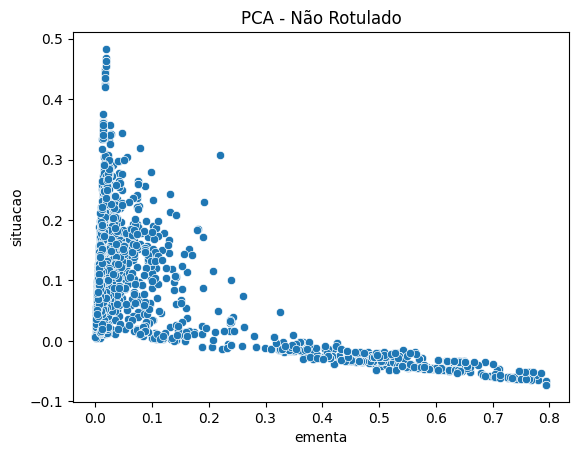

In [31]:
pca = TruncatedSVD(n_components=2)
X_pca = pca.fit_transform(X)
df_pca = pd.DataFrame(data=X_pca, columns=['ementa', 'situacao'])
df_pca["target"] = df["cor"].reset_index(drop=True)


sns.scatterplot(x='ementa', y="situacao", data=df_pca)
plt.title('PCA - Não Rotulado')
plt.show()

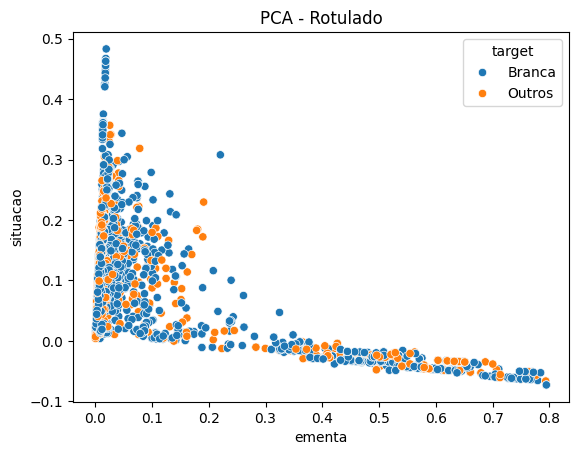

In [32]:
y_map = {0: 'Branca', 1: 'Outros'}

df_pca["target"] = df["cor"].map(y_map)

sns.scatterplot(x='ementa', y="situacao", hue="target", data=df_pca)
plt.title('PCA - Rotulado')
plt.show()

In [33]:
## Funçao para Avaliação dos Modelos

def evaluation_parametrics(name, y_test, y_pred):
    cm_test = confusion_matrix(y_test, y_pred)
    
    t1 = ConfusionMatrixDisplay(cm_test, display_labels=[
                                "Branca", 'Outros'])
    print("Classification Report for Data Test")
    print(classification_report(y_test, y_pred))
    t1.plot()

## Treino do Modelo

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
from imblearn.over_sampling import SMOTE

# transform the dataset
oversample = SMOTE()
X_train, y_train = oversample.fit_resample(X_train, y_train)

In [36]:
#K Fold

K = 5
kf = KFold(n_splits=K, shuffle=False) 

# Logistic Regression

In [37]:
model_LR = LogisticRegression(random_state=42, max_iter=1000, solver="liblinear", penalty="l2", C=3, tol=0.001)
cross_val_results_f1_scoreLR = cross_val_score(model_LR, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracyLR = cross_val_score(model_LR, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results_f1_scoreLR)
print('\n')

print("Media da Accuracy: ", cross_val_results_accuracyLR.mean())
print("Desvio Padrão da Accuracy: ", cross_val_results_accuracyLR.std())
print('\n')

print("Media da MACRO F1: ", cross_val_results_f1_scoreLR.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results_f1_scoreLR.std())

Resultado da Cross Validation:  [0.47116731 0.55042454 0.55525362 0.5471367  0.53599535]


Media da Accuracy:  0.7106610566047491
Desvio Padrão da Accuracy:  0.018938523910573594


Media da MACRO F1:  0.531995505703479
Desvio Padrão da MACRO F1:  0.031067322691159544


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.80      0.81      0.81       698
           1       0.49      0.47      0.48       266

    accuracy                           0.72       964
   macro avg       0.64      0.64      0.64       964
weighted avg       0.71      0.72      0.71       964



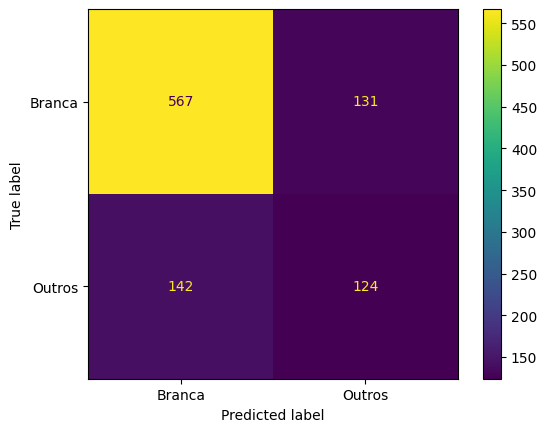

In [38]:
model_LR.fit(X_train, y_train)
y_pred = model_LR.predict(X_test)
evaluation_parametrics("Machine Learning - Logistic", y_test, y_pred)

# SGD Classifier

In [39]:
model_SGD = SGDClassifier(random_state=42, loss="squared_hinge", alpha=0.0001, learning_rate="constant", eta0=0.1, power_t=0.5, penalty="l2", tol=0.001, early_stopping=True, n_jobs=-1, class_weight="balanced")
cross_val_results_f1_scoreSGD = cross_val_score(model_SGD, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracySGD = cross_val_score(model_SGD, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results_f1_scoreSGD)
print('\n')

print("Media da Accuracy: ", cross_val_results_accuracySGD.mean())
print("Desvio Padrão da Accuracy: ", cross_val_results_accuracySGD.std())
print('\n')

print("Media da MACRO F1: ", cross_val_results_f1_scoreSGD.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results_f1_scoreSGD.std())

Resultado da Cross Validation:  [0.55518944 0.58055295 0.6042468  0.60724285 0.57995843]


Media da Accuracy:  0.6627193719488286
Desvio Padrão da Accuracy:  0.018488106133079687


Media da MACRO F1:  0.5854380925262299
Desvio Padrão da MACRO F1:  0.01896358164368915


# K Neighbors Classifier

In [40]:
model_KNeighbors = KNeighborsClassifier(n_neighbors=5, weights="distance", algorithm="auto", leaf_size=50, p=2 )
cross_val_results_f1_scoreKN = cross_val_score(model_KNeighbors, X, y, cv=kf, scoring="f1_macro", )
cross_val_results_accuracyKN = cross_val_score(model_KNeighbors, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results_f1_scoreKN)
print('\n')

print("Media da Accuracy: ", cross_val_results_accuracyKN.mean())
print("Desvio Padrão da Accuracy: ", cross_val_results_accuracyKN.std())
print('\n')

print("Media da MACRO F1: ", cross_val_results_f1_scoreKN.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results_f1_scoreKN.std())

Resultado da Cross Validation:  [0.49679613 0.55599334 0.54834189 0.57505013 0.50206763]


Media da Accuracy:  0.653582554517134
Desvio Padrão da Accuracy:  0.04297301853258521


Media da MACRO F1:  0.5356498255572777
Desvio Padrão da MACRO F1:  0.030869741983337088


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.87      0.29      0.43       698
           1       0.32      0.89      0.47       266

    accuracy                           0.46       964
   macro avg       0.60      0.59      0.45       964
weighted avg       0.72      0.46      0.45       964



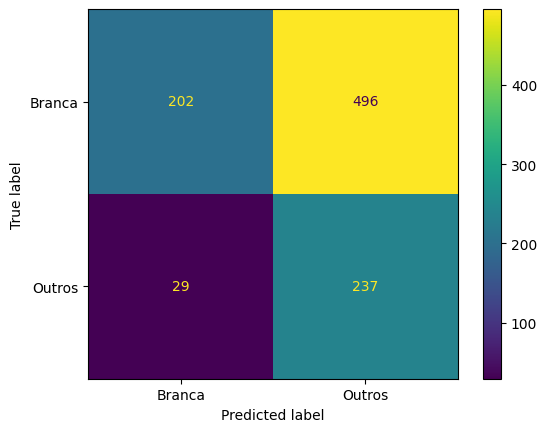

In [41]:
model_KNeighbors.fit(X_train, y_train)
y_pred = model_KNeighbors.predict(X_test)
evaluation_parametrics("Machine Learning - K Neighbors", y_test, y_pred)

# SVM (SUPPORT VECTOR MACHINE)

In [42]:
model_SVM = LinearSVC(random_state=42, loss='squared_hinge', max_iter=1000, penalty="l2", C=3, tol=0.0001, multi_class='ovr', dual=True, class_weight="balanced",  )
cross_val_results_f1_scoreSVM = cross_val_score(model_SVM, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracySVM = cross_val_score(model_SVM, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results_f1_scoreSVM)

print('\n')
print("Media da Accuracy: ", cross_val_results_accuracySVM.mean())
print("Desvio Padrão da Accuracy: ", cross_val_results_accuracySVM.std())
print('\n')

print("Media da MACRO F1: ", cross_val_results_f1_scoreSVM.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results_f1_scoreSVM.std())

Resultado da Cross Validation:  [0.5550907  0.58307074 0.6107293  0.59308669 0.59465698]


Media da Accuracy:  0.6697769763403609
Desvio Padrão da Accuracy:  0.011217859449509052


Media da MACRO F1:  0.5873268824381477
Desvio Padrão da MACRO F1:  0.01839491939738655


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.80      0.81      0.80       698
           1       0.48      0.46      0.47       266

    accuracy                           0.71       964
   macro avg       0.64      0.64      0.64       964
weighted avg       0.71      0.71      0.71       964



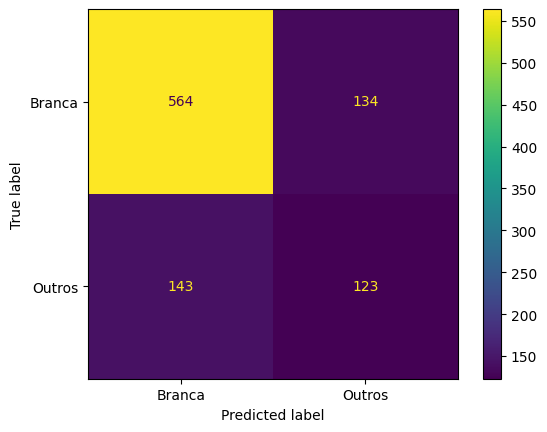

In [43]:
model_SVM.fit(X_train, y_train)
y_pred = model_SVM.predict(X_test)
evaluation_parametrics("Machine Learning - SVM", y_test, y_pred)

# Random Forest

In [44]:
model_Random_Forest = RandomForestClassifier(random_state=42, n_estimators=500, criterion="gini", max_features='sqrt', class_weight='balanced', n_jobs=-1, )
cross_val_results_f1_scoreRF = cross_val_score(model_Random_Forest, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracyRF = cross_val_score(model_Random_Forest, X, y, cv=kf, scoring="accuracy")


print("Resultado da Cross Validation: ", cross_val_results_f1_scoreRF)
print('\n')

print("Media da Accuracy: ", cross_val_results_accuracyRF.mean())
print("Desvio Padrão da Accuracy: ", cross_val_results_accuracyRF.std())
print('\n')

print("Media da MACRO F1: ", cross_val_results_f1_scoreRF.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results_f1_scoreRF.std())

Resultado da Cross Validation:  [0.42973807 0.51951832 0.51211423 0.54536871 0.57396807]


Media da Accuracy:  0.7160621415614242
Desvio Padrão da Accuracy:  0.016051369684702728


Media da MACRO F1:  0.516141479453051
Desvio Padrão da MACRO F1:  0.04835559144911805


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.77      0.90      0.83       698
           1       0.53      0.29      0.38       266

    accuracy                           0.73       964
   macro avg       0.65      0.60      0.60       964
weighted avg       0.71      0.73      0.71       964



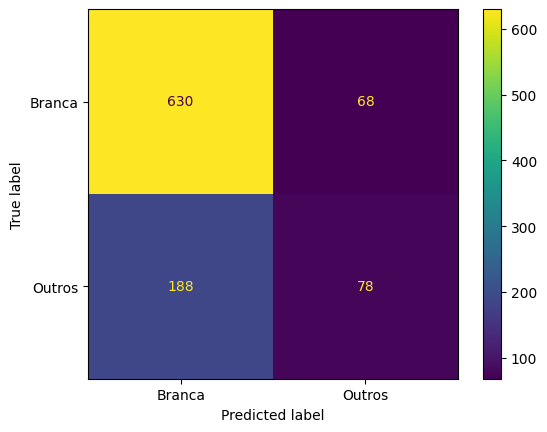

In [45]:
model_Random_Forest.fit(X_train, y_train)
y_pred = model_Random_Forest.predict(X_test)
evaluation_parametrics("Machine Learning - Random Forest", y_test, y_pred)

# Decision Tree

In [46]:
model_Decision_Tree = DecisionTreeClassifier(random_state=42, criterion="entropy", splitter="random", class_weight="balanced", ccp_alpha=0.0001)

cross_val_results_f1_scoreDT = cross_val_score(model_Decision_Tree, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracyDT = cross_val_score(model_Decision_Tree, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results_f1_scoreDT)
print('\n')

print("Media da Accuracy: ", cross_val_results_accuracyDT.mean())
print("Desvio Padrão da Accuracy: ", cross_val_results_accuracyDT.std())
print('\n')

print("Media da MACRO F1: ", cross_val_results_f1_scoreDT.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results_f1_scoreDT.std())

Resultado da Cross Validation:  [0.53045333 0.5141206  0.55545393 0.60291116 0.59367866]


Media da Accuracy:  0.6349219891159628
Desvio Padrão da Accuracy:  0.023525107304387644


Media da MACRO F1:  0.5593235343972569
Desvio Padrão da MACRO F1:  0.0345598708465765


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.79      0.75      0.77       698
           1       0.42      0.48      0.45       266

    accuracy                           0.67       964
   macro avg       0.60      0.61      0.61       964
weighted avg       0.69      0.67      0.68       964



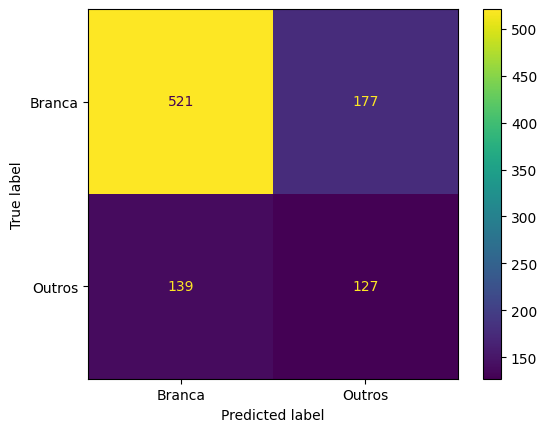

In [47]:
model_Decision_Tree.fit(X_train, y_train)
y_pred = model_Decision_Tree.predict(X_test)
evaluation_parametrics("Machine Learning - Decision Tree", y_test, y_pred)

In [48]:
## Funçao para Avaliação dos Modelos
# Refazer essa parte 
import numpy as np
from sklearn.metrics import f1_score, accuracy_score

branca:int = df["cor"].loc[(df["cor"] == 0)].value_counts()
# print(int(branca))
prob_brancos = (int(branca)/len(df["cor"]))

outros:int = df["cor"].loc[(df["cor"] == 1)].value_counts()

prob_outros = (int(outros)/len(df["cor"]))

rng = np.random.default_rng(62)
numbers = rng.random(len(y_test))

resultado_sem_vies_accuracy = []
resultado_sem_vies_f1_score = []
rng_options = [8, 32, 42, 64, 128]

for _ in range(5):
    rng = np.random.default_rng(rng_options[_])
    numbers = rng.random(len(y_test))

    balanceamento = [y_test.loc[y_test == 0].sample(1)  if i < prob_brancos else y_test.loc[y_test == 1].sample(1) for i in numbers]
    new_df = pd.concat(balanceamento)
    
    resultado_sem_vies_accuracy.append(accuracy_score(y_test, new_df))
    resultado_sem_vies_f1_score.append(f1_score(y_test, new_df, average='macro'))

In [49]:
resultado_sem_vies_accuracy

[0.6006224066390041,
 0.5674273858921162,
 0.5819502074688797,
 0.5881742738589212,
 0.5943983402489627]

In [50]:
sem_vies_accuracy = pd.DataFrame(resultado_sem_vies_accuracy)
sem_vies_f1_score = pd.DataFrame(resultado_sem_vies_f1_score)

print(f' Média da Accuracy: {sem_vies_accuracy.mean()[0]}')
print(f' Desvio Padrão Accuracy: {sem_vies_accuracy.std()[0]}')

print('\n')

print(f' Média da Macro F1: {sem_vies_f1_score.mean()[0]}')
print(f' Desvio Padrão da Macro F1: {sem_vies_f1_score.std()[0]}')


 Média da Accuracy: 0.5865145228215768
 Desvio Padrão Accuracy: 0.012738656790878627


 Média da Macro F1: 0.48859758045432516
 Desvio Padrão da Macro F1: 0.011329817404823759


# Aleatório Organizado

In [51]:
resultado_aleatorio_f1_score = []
resultado_aleatorio_accuracy = []
rng_options = [8, 32, 42, 64, 1]

for _ in range(5):
    aleatorio = []
    rng = np.random.default_rng(rng_options[_])
    numbers = rng.random(len(y_test))

    for i in range(int(len(numbers))):

        if numbers[i] < 0.5:  
            aleatorio.append(y_test.loc[y_test == 0].sample(1))
        else:
            aleatorio.append(y_test.loc[y_test == 1].sample(1))

    new_df = pd.concat(aleatorio)
    
    resultado_aleatorio_accuracy.append(accuracy_score(y_test, new_df))
    resultado_aleatorio_f1_score.append(f1_score(y_test, new_df, average='macro'))


In [52]:
aleatorio_accuracy = pd.DataFrame(resultado_aleatorio_accuracy)
aleatorio_f1_score = pd.DataFrame(resultado_aleatorio_f1_score)

print(f' Média da Accuracy: {aleatorio_accuracy.mean()[0]}')
print(f' Desvio Padrão Accuracy: {aleatorio_accuracy.std()[0]}')

print('\n')

print(f' Média da Macro F1: {aleatorio_f1_score.mean()[0]}')
print(f' Desvio Padrão da Macro F1: {aleatorio_f1_score.std()[0]}')

 Média da Accuracy: 0.4983402489626556
 Desvio Padrão Accuracy: 0.017274198303624307


 Média da Macro F1: 0.47108767401895635
 Desvio Padrão da Macro F1: 0.01661267086026054


# P_VALUE

In [53]:
resultado_melhor_resultado_accuracy = cross_val_results_accuracyRF
resultado_melhor_resultado_f1_score = cross_val_results_f1_scoreRF

# LOGISTIC REGRESSION

In [54]:
from scipy.stats import ttest_rel

p_value_accuracy_aleatorioLR = ttest_rel(resultado_aleatorio_accuracy, cross_val_results_accuracyLR)
p_value_f1_score_aleatorioLR = ttest_rel(resultado_aleatorio_f1_score, cross_val_results_f1_scoreLR)

p_value_accuracy_sem_viesLR = ttest_rel(resultado_sem_vies_accuracy, cross_val_results_accuracyLR)
p_value_f1_score_sem_viesLR = ttest_rel(resultado_sem_vies_f1_score, cross_val_results_f1_scoreLR)

p_value_accuracy_melhor_resultado = ttest_rel(resultado_melhor_resultado_accuracy, cross_val_results_accuracyLR)
p_value_f1_score_melhor_resultado = ttest_rel(resultado_melhor_resultado_f1_score, cross_val_results_f1_scoreLR)

p_value_accuracy_LR = ttest_rel(cross_val_results_accuracyLR, cross_val_results_accuracyLR)
p_value_f1_score_LR = ttest_rel(cross_val_results_f1_scoreLR, cross_val_results_f1_scoreLR)



print('\nALEATÓRIO')
print(f' Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  {p_value_accuracy_aleatorioLR.pvalue} \n')
print(f' Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  {p_value_f1_score_aleatorioLR.pvalue} \n')

print('\nSEM VIÉS')
print(f' Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  {p_value_accuracy_sem_viesLR.pvalue} \n')
print(f' Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  {p_value_f1_score_sem_viesLR.pvalue} \n')

print('\nMelhor Modelo')
print(f' Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  {p_value_accuracy_melhor_resultado.pvalue} \n')
print(f' Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  {p_value_f1_score_melhor_resultado.pvalue} \n')

print('\nLogist Regression')
print(f' Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  {p_value_accuracy_LR.pvalue} \n')
print(f' Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  {p_value_f1_score_LR.pvalue} \n')



ALEATÓRIO
 Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  0.00020245465603511368 

 Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  0.03174131424098004 


SEM VIÉS
 Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  0.0008165027194331845 

 Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  0.07972176938908582 


Melhor Modelo
 Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  0.6702036742568909 

 Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  0.36041780455944467 


Logist Regression
 Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  nan 

 Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  nan 



# SGD

In [55]:
p_value_accuracy_aleatorioSGD = ttest_rel(resultado_aleatorio_accuracy, cross_val_results_accuracySGD)
p_value_f1_score_aleatorioSGD = ttest_rel(resultado_aleatorio_f1_score, cross_val_results_f1_scoreSGD)

p_value_accuracy_sem_viesSGD = ttest_rel(resultado_sem_vies_accuracy, cross_val_results_accuracySGD)
p_value_f1_score_sem_viesSGD = ttest_rel(resultado_sem_vies_f1_score, cross_val_results_f1_scoreSGD)

p_value_accuracy_melhor_resultado = ttest_rel(resultado_melhor_resultado_accuracy, cross_val_results_accuracySGD)
p_value_f1_score_melhor_resultado = ttest_rel(resultado_melhor_resultado_f1_score, cross_val_results_f1_scoreSGD)

p_value_accuracy_LR = ttest_rel(cross_val_results_accuracyLR, cross_val_results_accuracySGD)
p_value_f1_score_LR = ttest_rel(cross_val_results_f1_scoreLR, cross_val_results_f1_scoreSGD)


print('ALEATÓRIO\n')
print(f' Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  {p_value_accuracy_aleatorioSGD.pvalue} \n')
print(f' Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  {p_value_f1_score_aleatorioSGD.pvalue} \n')

print('SEM VIÉS\n')
print(f' Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  {p_value_accuracy_sem_viesSGD.pvalue} \n')
print(f' Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  {p_value_f1_score_sem_viesSGD.pvalue} \n')

print('\nMelhor Modelo')
print(f' Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  {p_value_accuracy_melhor_resultado.pvalue} \n')
print(f' Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  {p_value_f1_score_melhor_resultado.pvalue} \n')

print('\nLogist Regression')
print(f' Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  {p_value_accuracy_LR.pvalue} \n')
print(f' Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  {p_value_f1_score_LR.pvalue} \n')


ALEATÓRIO

 Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  0.0006194117566213217 

 Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  0.0011366384768776495 

SEM VIÉS

 Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  0.004692186623150757 

 Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  0.0012484840151766878 


Melhor Modelo
 Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  0.015043758268908788 

 Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  0.024724382606167026 


Logist Regression
 Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  0.0003317691317177185 

 Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  0.0040910037661805775 



# KNN

In [56]:
p_value_accuracy_aleatorioKN = ttest_rel(resultado_aleatorio_accuracy, cross_val_results_accuracyKN)
p_value_f1_score_aleatorioKN = ttest_rel(resultado_aleatorio_f1_score, cross_val_results_f1_scoreKN)

p_value_accuracy_sem_viesKN = ttest_rel(resultado_sem_vies_accuracy, cross_val_results_accuracyKN)
p_value_f1_score_sem_viesKN = ttest_rel(resultado_sem_vies_f1_score, cross_val_results_f1_scoreKN)

p_value_accuracy_melhor_resultado = ttest_rel(resultado_melhor_resultado_accuracy, cross_val_results_accuracyKN)
p_value_f1_score_melhor_resultado = ttest_rel(resultado_melhor_resultado_f1_score, cross_val_results_f1_scoreKN)

p_value_accuracy_LR = ttest_rel(cross_val_results_accuracyLR, cross_val_results_accuracyKN)
p_value_f1_score_LR = ttest_rel(cross_val_results_f1_scoreLR, cross_val_results_f1_scoreKN)


print('\nALEATÓRIO')
print(f' Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  {p_value_accuracy_aleatorioKN.pvalue} \n')
print(f' Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  {p_value_f1_score_aleatorioKN.pvalue} \n')

print('\nSEM VIÉS')
print(f' Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  {p_value_accuracy_sem_viesKN.pvalue} \n')
print(f' Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  {p_value_f1_score_sem_viesKN.pvalue} \n')

print('\nMelhor Modelo')
print(f' Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  {p_value_accuracy_melhor_resultado.pvalue} \n')
print(f' Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  {p_value_f1_score_melhor_resultado.pvalue} \n')


print('\nLogist Regression')
print(f' Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  {p_value_accuracy_LR.pvalue} \n')
print(f' Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  {p_value_f1_score_LR.pvalue} \n')



ALEATÓRIO
 Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  0.00582632686650255 

 Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  0.04172684745307544 


SEM VIÉS
 Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  0.05388344909956363 

 Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  0.07225129851267657 


Melhor Modelo
 Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  0.06669610867362807 

 Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  0.45766698369887426 


Logist Regression
 Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  0.015267293967174597 

 Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  0.7645914263866807 



# SVM

In [57]:
p_value_accuracy_aleatorioSVM = ttest_rel(resultado_aleatorio_accuracy, cross_val_results_accuracySVM)
p_value_f1_score_aleatorioSVM = ttest_rel(resultado_aleatorio_f1_score, cross_val_results_f1_scoreSVM)

p_value_accuracy_sem_viesSVM = ttest_rel(resultado_sem_vies_accuracy, cross_val_results_accuracySVM)
p_value_f1_score_sem_viesSVM = ttest_rel(resultado_sem_vies_f1_score, cross_val_results_f1_scoreSVM)

p_value_accuracy_melhor_resultado = ttest_rel(resultado_melhor_resultado_accuracy, cross_val_results_accuracySVM)
p_value_f1_score_melhor_resultado = ttest_rel(resultado_melhor_resultado_f1_score, cross_val_results_f1_scoreSVM)

p_value_accuracy_LR = ttest_rel(cross_val_results_accuracyLR, cross_val_results_accuracySVM)
p_value_f1_score_LR = ttest_rel(cross_val_results_f1_scoreLR, cross_val_results_f1_scoreSVM)



print('\nALEATÓRIO')
print(f' Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  {p_value_accuracy_aleatorioSVM.pvalue} \n')
print(f' Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  {p_value_f1_score_aleatorioSVM.pvalue} \n')

print('\nSEM VIÉS')
print(f' Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  {p_value_accuracy_sem_viesSVM.pvalue} \n')
print(f' Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  {p_value_f1_score_sem_viesSVM.pvalue} \n')

print('\nMelhor Modelo')
print(f' Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  {p_value_accuracy_melhor_resultado.pvalue} \n')
print(f' Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  {p_value_f1_score_melhor_resultado.pvalue} \n')

print('\nLogist Regression')
print(f' Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  {p_value_accuracy_LR.pvalue} \n')
print(f' Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  {p_value_f1_score_LR.pvalue} \n')




ALEATÓRIO
 Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  0.00018845811319807563 

 Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  0.0005150511918272415 


SEM VIÉS
 Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  0.001359374746187264 

 Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  0.0008760996410959364 


Melhor Modelo
 Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  0.010900865333582498 

 Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  0.018337607877418536 


Logist Regression
 Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  0.0013377147222468093 

 Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  0.002823670569926241 



# RANDOM FOREST

In [58]:
p_value_accuracy_aleatorioRF = ttest_rel(resultado_aleatorio_accuracy, cross_val_results_accuracyRF)
p_value_f1_score_aleatorioRF = ttest_rel(resultado_aleatorio_f1_score, cross_val_results_f1_scoreRF)

p_value_accuracy_sem_viesRF = ttest_rel(resultado_sem_vies_accuracy, cross_val_results_accuracyRF)
p_value_f1_score_sem_viesRF = ttest_rel(resultado_sem_vies_f1_score, cross_val_results_f1_scoreRF)

p_value_accuracy_melhor_resultado = ttest_rel(resultado_melhor_resultado_accuracy, cross_val_results_accuracyRF)
p_value_f1_score_melhor_resultado = ttest_rel(resultado_melhor_resultado_f1_score, cross_val_results_f1_scoreRF)


p_value_accuracy_LR = ttest_rel(cross_val_results_accuracyLR, cross_val_results_accuracyRF)
p_value_f1_score_LR = ttest_rel(cross_val_results_f1_scoreLR, cross_val_results_f1_scoreRF)

print('\nALEATÓRIO')
print(f'Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  {p_value_accuracy_aleatorioRF.pvalue} \n')
print(f'Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  {p_value_f1_score_aleatorioRF.pvalue} \n')

print('\nSEM VIÉS')
print(f'Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  {p_value_accuracy_sem_viesRF.pvalue} \n')
print(f'Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  {p_value_f1_score_sem_viesRF.pvalue} \n')

print('\nMelhor Modelo')
print(f'Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  {p_value_accuracy_melhor_resultado.pvalue} \n')
print(f'Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  {p_value_f1_score_melhor_resultado.pvalue} \n')

print('\nLogist Regression')
print(f' Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  {p_value_accuracy_LR.pvalue} \n')
print(f' Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  {p_value_f1_score_LR.pvalue} \n')




ALEATÓRIO
Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  3.178473560319774e-05 

Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  0.13279866443625618 


SEM VIÉS
Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  0.00039916155092729086 

Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  0.32768410929540076 


Melhor Modelo
Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  nan 

Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  nan 


Logist Regression
 Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  0.6702036742568909 

 Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  0.36041780455944467 



# DECISION TREE

In [59]:
p_value_accuracy_aleatorioDT = ttest_rel(resultado_aleatorio_accuracy, cross_val_results_accuracyDT)
p_value_f1_score_aleatorioDT = ttest_rel(resultado_aleatorio_f1_score, cross_val_results_f1_scoreDT)

p_value_accuracy_sem_viesDT = ttest_rel(resultado_sem_vies_accuracy, cross_val_results_accuracyDT)
p_value_f1_score_sem_viesDT = ttest_rel(resultado_sem_vies_f1_score, cross_val_results_f1_scoreDT)

p_value_accuracy_melhor_resultado = ttest_rel(resultado_melhor_resultado_accuracy, cross_val_results_accuracyDT)
p_value_f1_score_melhor_resultado = ttest_rel(resultado_melhor_resultado_f1_score, cross_val_results_f1_scoreDT)

p_value_accuracy_LR = ttest_rel(cross_val_results_accuracyLR, cross_val_results_accuracyDT)
p_value_f1_score_LR = ttest_rel(cross_val_results_f1_scoreLR, cross_val_results_f1_scoreDT)



print('\nALEATÓRIO')
print(f'Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  {p_value_accuracy_aleatorioDT.pvalue} \n')
print(f'Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  {p_value_f1_score_aleatorioDT.pvalue} \n')

print('\nSEM VIÉS')
print(f'Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  {p_value_accuracy_sem_viesDT.pvalue} \n')
print(f'Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  {p_value_f1_score_sem_viesDT.pvalue} \n')

print('\nMelhor Modelo')
print(f'Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  {p_value_accuracy_melhor_resultado.pvalue} \n')
print(f'Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  {p_value_f1_score_melhor_resultado.pvalue} \n')


print('\nLogist Regression')
print(f' Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  {p_value_accuracy_LR.pvalue} \n')
print(f' Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  {p_value_f1_score_LR.pvalue} \n')



ALEATÓRIO
Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  0.0003913688135918949 

Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  0.00571949444933146 


SEM VIÉS
Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  0.00838919472542953 

Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  0.009469173926845077 


Melhor Modelo
Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  0.010429383412050694 

Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  0.07364782824944806 


Logist Regression
 Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  0.01840409984106588 

 Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  0.2319641710166759 



# SEM VIES

In [60]:

p_value_accuracy_sem_vies = ttest_rel(resultado_sem_vies_accuracy, resultado_sem_vies_accuracy)
p_value_f1_score_sem_vies = ttest_rel(resultado_sem_vies_f1_score, resultado_sem_vies_f1_score)

p_value_accuracy_aleatorio = ttest_rel(resultado_sem_vies_accuracy, resultado_aleatorio_accuracy)
p_value_f1_score_aleatorio = ttest_rel(resultado_sem_vies_f1_score, resultado_aleatorio_f1_score)

p_value_accuracy_melhor_resultado = ttest_rel(resultado_melhor_resultado_accuracy, resultado_sem_vies_accuracy)
p_value_f1_score_melhor_resultado = ttest_rel(resultado_melhor_resultado_f1_score, resultado_sem_vies_f1_score)

p_value_accuracy_LR = ttest_rel(cross_val_results_accuracyLR, resultado_sem_vies_accuracy)
p_value_f1_score_LR = ttest_rel(cross_val_results_f1_scoreLR, resultado_sem_vies_f1_score)



print('\nALEATÓRIO')
print(f' Valor do P_VALUE para ACURÁCIA DE SEM VIES:  {p_value_accuracy_aleatorio.pvalue} \n')
print(f' Valor do P_VALUE para MACRO F1 DE SEM VIES:  {p_value_f1_score_aleatorio.pvalue} \n')

print('\nSEM VIES')
print(f'Valor do P_VALUE para ACURÁCIA DE SEM VIES:  {p_value_accuracy_sem_vies.pvalue} \n')
print(f'Valor do P_VALUE para MACRO F1 DE SEM VIES:  {p_value_f1_score_sem_vies.pvalue} \n')

print('\nMelhor Modelo')
print(f'Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  {p_value_accuracy_melhor_resultado.pvalue} \n')
print(f'Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  {p_value_f1_score_melhor_resultado.pvalue} \n')


print('\nLogist Regression')
print(f' Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  {p_value_accuracy_LR.pvalue} \n')
print(f' Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  {p_value_f1_score_LR.pvalue} \n')



ALEATÓRIO
 Valor do P_VALUE para ACURÁCIA DE SEM VIES:  0.00011220092824937597 

 Valor do P_VALUE para MACRO F1 DE SEM VIES:  0.015032032451396492 


SEM VIES
Valor do P_VALUE para ACURÁCIA DE SEM VIES:  nan 

Valor do P_VALUE para MACRO F1 DE SEM VIES:  nan 


Melhor Modelo
Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  0.00039916155092729086 

Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  0.32768410929540076 


Logist Regression
 Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  0.0008165027194331845 

 Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  0.07972176938908582 



# Aleatório

In [61]:

p_value_accuracy_aleatorio = ttest_rel(resultado_aleatorio_accuracy, resultado_aleatorio_accuracy)
p_value_f1_score_aleatorio = ttest_rel(resultado_aleatorio_f1_score, resultado_aleatorio_f1_score)

p_value_accuracy_sem_vies = ttest_rel(resultado_sem_vies_accuracy, resultado_aleatorio_accuracy)
p_value_f1_score_sem_vies = ttest_rel(resultado_sem_vies_f1_score, resultado_aleatorio_f1_score)

p_value_accuracy_melhor_resultado = ttest_rel(resultado_melhor_resultado_accuracy, resultado_aleatorio_accuracy)
p_value_f1_score_melhor_resultado = ttest_rel(resultado_melhor_resultado_f1_score, resultado_aleatorio_f1_score)

p_value_accuracy_LR = ttest_rel(cross_val_results_accuracyLR, resultado_aleatorio_accuracy)
p_value_f1_score_LR = ttest_rel(cross_val_results_f1_scoreLR, resultado_aleatorio_f1_score)

print('Aleatório')
print(f' Valor do P_VALUE para ACURÁCIA DE ALEATÓRIO:  {p_value_accuracy_aleatorio.pvalue} \n')
print(f' Valor do P_VALUE para MACRO F1 DE ALEATÓRIO:  {p_value_f1_score_aleatorio.pvalue} \n')

print('SEM VIES')
print(f' Valor do P_VALUE para ACURÁCIA DE SEM VIES:  {p_value_accuracy_sem_vies.pvalue} \n')
print(f' Valor do P_VALUE para MACRO F1 DE SEM VIES:  {p_value_f1_score_sem_vies.pvalue} \n')

print('MELHOR RESULTADO')
print(f' Valor do P_VALUE para ACURÁCIA DE MELHOR RESULTADO:  {p_value_accuracy_melhor_resultado.pvalue} \n')
print(f' Valor do P_VALUE para MACRO F1 DE MELHOR RESULTADO:  {p_value_f1_score_melhor_resultado.pvalue} \n')

print('LOGISTIC RESULTADO')
print(f' Valor do P_VALUE para ACURÁCIA:   {p_value_accuracy_LR.pvalue} \n')
print(f' Valor do P_VALUE para MACRO F1:  {p_value_accuracy_LR.pvalue} \n')


Aleatório
 Valor do P_VALUE para ACURÁCIA DE ALEATÓRIO:  nan 

 Valor do P_VALUE para MACRO F1 DE ALEATÓRIO:  nan 

SEM VIES
 Valor do P_VALUE para ACURÁCIA DE SEM VIES:  0.00011220092824937597 

 Valor do P_VALUE para MACRO F1 DE SEM VIES:  0.015032032451396492 

MELHOR RESULTADO
 Valor do P_VALUE para ACURÁCIA DE MELHOR RESULTADO:  3.178473560319774e-05 

 Valor do P_VALUE para MACRO F1 DE MELHOR RESULTADO:  0.13279866443625618 

LOGISTIC RESULTADO
 Valor do P_VALUE para ACURÁCIA:   0.00020245465603511368 

 Valor do P_VALUE para MACRO F1:  0.00020245465603511368 

